# Smart Microgrid Renewable Energy Dispatch & Storage Optimizer

This notebook demonstrates the complete project workflow:

**Dataset → ML Surrogate → Dispatch Simulation → Bayesian Optimisation Results → Validation → Final Summary**

The Streamlit dashboard is kept as the deployment/interface layer.  
This notebook is intended to provide a reproducible, readable project walkthrough on GitHub.

> **Note:** The Bayesian optimisation results shown here are loaded from the saved project report rather than rerunning the expensive optimisation loop every time the notebook opens.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

# If the notebook is opened from the notebooks/ folder, move to project root.
if (ROOT / "data").exists() is False and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

CODE = ROOT / "code"
DATA = ROOT / "data"
MODELS = ROOT / "models"
FIGURES = ROOT / "figures"

sys.path.insert(0, str(CODE))

print("Project root:", ROOT)
print("Data folder:", DATA)
print("Models folder:", MODELS)


Project root: C:\Users\harsh\OneDrive\Desktop\InshipAssignment\main_project\microgrid_project_code
Data folder: C:\Users\harsh\OneDrive\Desktop\InshipAssignment\main_project\microgrid_project_code\data
Models folder: C:\Users\harsh\OneDrive\Desktop\InshipAssignment\main_project\microgrid_project_code\models


## 1. Load the Microgrid Dataset

In [2]:
df = pd.read_csv(DATA / "microgrid_timeseries.csv")

df["date_id"] = (df["timestamp_h"] // 24).astype(int)
df["day"] = df["date_id"] + 1

print(f"Records : {len(df):,}")
print(f"Days    : {df['day'].nunique()}")
print(f"Columns : {len(df.columns)}")

display(df.head())


Records : 2,880
Days    : 120
Columns : 17


,timestamp_h,day_of_year,hour_of_day,day_of_week,solar_irradiance_wm2,wind_speed_ms,ambient_temp_c,humidity_pct,pv_output_kw,wind_output_kw,load_demand_kw,grid_tariff_inr_per_kwh,net_demand_kw,pv_ramp_kw,load_ramp_kw,date_id,day
0,0,0,0,0,0.0,6.20,5.29,79.47,0.0,13.448,160.450,3.75,147.002,0.0,0.000,0,1
1,1,0,1,0,0.0,6.50,5.04,72.54,0.0,17.677,160.318,3.75,142.641,0.0,-0.132,0,1
2,2,0,2,0,0.0,7.65,4.28,68.75,0.0,41.461,156.701,3.75,115.240,0.0,-3.617,0,1
3,3,0,3,0,0.0,7.91,4.54,85.88,0.0,48.706,158.414,3.75,109.708,0.0,1.713,0,1
4,4,0,4,0,0.0,7.41,3.37,72.92,0.0,35.268,166.724,3.75,131.456,0.0,8.310,0,1


## 2. Dataset Quality & Microgrid Capacity Checks

In [3]:
checks = {
    "Missing values": int(df.isna().sum().sum()),
    "Maximum PV output (kW)": round(float(df["pv_output_kw"].max()), 2),
    "Maximum wind output (kW)": round(float(df["wind_output_kw"].max()), 2),
    "Minimum load (kW)": round(float(df["load_demand_kw"].min()), 2),
    "Maximum load (kW)": round(float(df["load_demand_kw"].max()), 2),
}

display(pd.DataFrame([checks]))

assert df.isna().sum().sum() == 0
assert df["pv_output_kw"].max() <= 500.001
assert df["wind_output_kw"].max() <= 300.001

print("✓ Dataset quality checks passed")


,Missing values,Maximum PV output (kW),Maximum wind output (kW),Minimum load (kW),Maximum load (kW)
0,0,500.0,137.03,76.26,251.55


✓ Dataset quality checks passed


## 3. Renewable Generation Profile

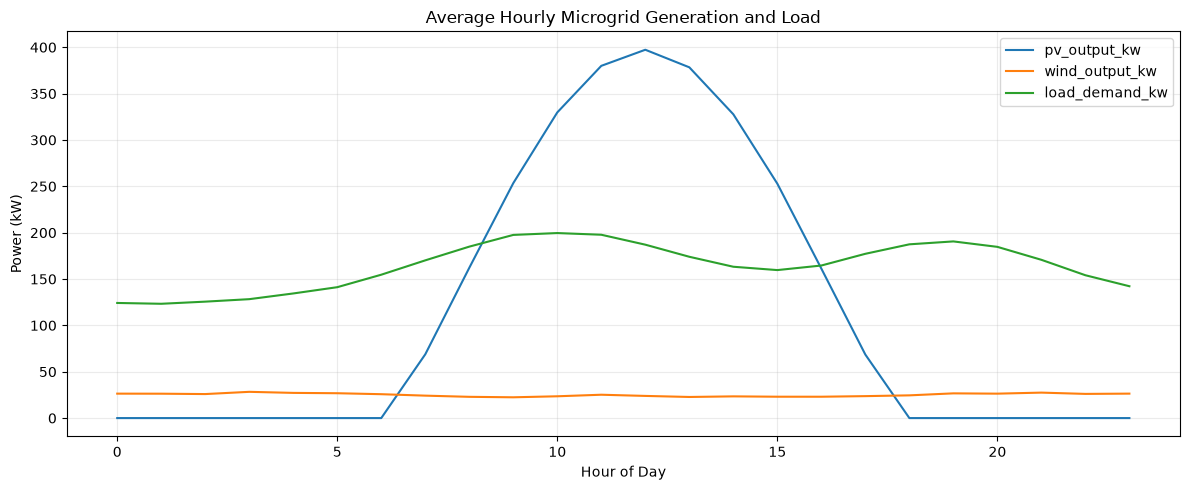

In [4]:
hourly = df.groupby("hour_of_day")[
    ["pv_output_kw", "wind_output_kw", "load_demand_kw"]
].mean()

ax = hourly.plot(figsize=(12, 5))
ax.set_title("Average Hourly Microgrid Generation and Load")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Power (kW)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Renewable Yield Heatmap

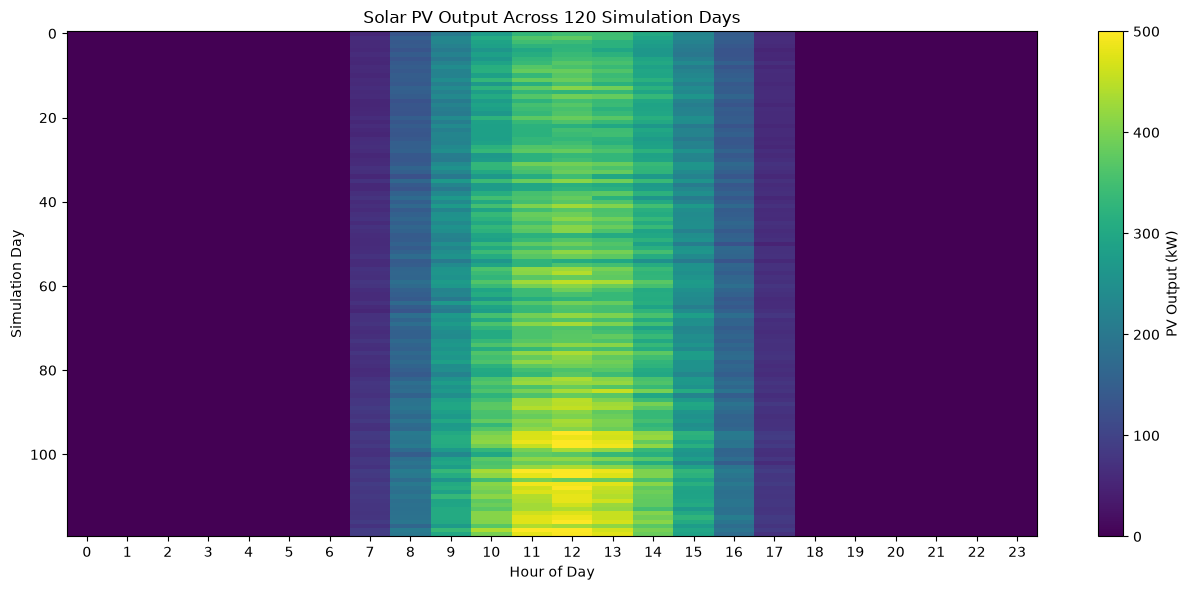

In [5]:
solar = df.pivot_table(
    index="day",
    columns="hour_of_day",
    values="pv_output_kw",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(solar, aspect="auto", interpolation="nearest")
ax.set_title("Solar PV Output Across 120 Simulation Days")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Simulation Day")
ax.set_xticks(range(24))
fig.colorbar(im, ax=ax, label="PV Output (kW)")
plt.tight_layout()
plt.show()


## 5. Machine-Learning Surrogate Model

In [6]:
surrogate_report_file = MODELS / "surrogate_report.json"

with open(surrogate_report_file) as f:
    surrogate_report = json.load(f)

print("Selected backend:", surrogate_report.get("selected_backend"))
print("Training samples:", surrogate_report.get("n_train"))
print("Testing samples :", surrogate_report.get("n_test"))

metric_rows = []

for backend, metrics in surrogate_report.get("backend_results", {}).items():
    for target, values in metrics.items():
        metric_rows.append({
            "Backend": backend,
            "Target": target,
            "MAE": values["MAE"],
            "RMSE": values["RMSE"],
            "R²": values["R2"],
        })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

print("\nAverage R²:")
display(pd.DataFrame(
    surrogate_report.get("avg_r2_by_backend", {}),
    index=["Average R²"]
).T)


Selected backend: HistGradientBoosting
Training samples: 2304
Testing samples : 576


,Backend,Target,MAE,RMSE,R²
0,RandomForest,pv_output_kw,8.267,14.782,0.9928
1,RandomForest,wind_output_kw,2.410,3.655,0.9601
2,RandomForest,load_demand_kw,8.171,10.283,0.8790
3,HistGradientBoosting,pv_output_kw,3.692,9.639,0.9970
4,HistGradientBoosting,wind_output_kw,0.198,0.982,0.9971
5,HistGradientBoosting,load_demand_kw,7.311,9.295,0.9012



Average R²:


,Average R²
RandomForest,0.9440
HistGradientBoosting,0.9651


## 6. ML Live Prediction Example

In [7]:
import joblib

saved_model = joblib.load(MODELS / "surrogate_model.joblib")
model = saved_model["model"]

hour = 12
sample = pd.DataFrame([{
    "solar_irradiance_wm2": 500,
    "wind_speed_ms": 7,
    "ambient_temp_c": 28,
    "humidity_pct": 60,
    "hour_sin": np.sin(2 * np.pi * hour / 24),
    "hour_cos": np.cos(2 * np.pi * hour / 24),
    "day_of_week": 2,
}])

prediction = model.predict(sample.to_numpy())[0]

forecast = pd.DataFrame({
    "Quantity": ["PV Output", "Wind Output", "Load Demand"],
    "Prediction (kW)": [
        max(0, min(float(prediction[0]), 500)),
        max(0, min(float(prediction[1]), 300)),
        max(float(prediction[2]), 0),
    ],
})

display(forecast)


,Quantity,Prediction (kW)
0,PV Output,447.747854
1,Wind Output,105.185720
2,Load Demand,148.454389


## 7. Rule-Based Battery Dispatch Simulation

In [8]:
from dispatch_optimizer import pick_regime_day, simulate_day, BOUNDS

with open(MODELS / "optimizer_report.json") as f:
    optimizer_report = json.load(f)

dispatch_rows = []

for scenario in ["Sunny", "High Wind", "Overcast"]:
    day_df = pick_regime_day(df, scenario)
    theta = np.array([
        optimizer_report[scenario]["theta"][name]
        for name in [
            "charge_price_thr",
            "discharge_price_thr",
            "max_chg_frac",
            "max_dis_frac",
            "reserve_soc",
            "diesel_trigger_frac",
            "deg_weight",
        ]
    ])

    cost, breakdown, log = simulate_day(theta, day_df)

    dispatch_rows.append({
        "Scenario": scenario,
        "Cost (INR)": round(cost, 2),
        "Grid Cost": round(breakdown["grid"], 2),
        "Diesel Cost": round(breakdown["diesel"], 2),
        "Degradation Cost": round(breakdown["degradation"], 2),
        "Carbon Cost": round(breakdown["carbon"], 2),
    })

dispatch_summary = pd.DataFrame(dispatch_rows)
display(dispatch_summary)


,Scenario,Cost (INR),Grid Cost,Diesel Cost,Degradation Cost,Carbon Cost
0,Sunny,2626.49,2584.22,0.0,42.27,0.0
1,High Wind,1966.01,1756.67,0.0,209.34,0.0
2,Overcast,9251.89,9220.56,0.0,31.33,0.0


## 8. Bayesian Optimisation Results

The integrated optimisation stage is computationally heavier than the dashboard and is **not rerun automatically** in this notebook.

Instead, the notebook reads the saved optimisation output generated by `integrated_optimizer.py`.

This keeps the GitHub notebook fast to open while preserving the actual measured results.


In [9]:
integrated_file = MODELS / "integrated_optimizer_report.json"

if integrated_file.exists():
    with open(integrated_file) as f:
        integrated_report = json.load(f)

    results = integrated_report.get("results", {})

    rows = []
    for scenario, result in results.items():
        if isinstance(result, dict):
            baseline = float(result.get("baseline_cost", 0))
            optimized = float(result.get("optimized_cost", 0))
            savings = float(result.get("savings", baseline - optimized))

            rows.append({
                "Scenario": scenario,
                "Baseline Cost (INR)": baseline,
                "Optimised Cost (INR)": optimized,
                "Savings (INR)": savings,
                "Savings (%)": (
                    savings / baseline * 100 if baseline else 0
                ),
            })

    integrated_summary = pd.DataFrame(rows)
    display(integrated_summary)

else:
    print("Integrated optimisation report not found in this project snapshot.")
    print("Run integrated_optimizer.py once in the current project, then rerun this cell.")


,Scenario,Baseline Cost (INR),Optimised Cost (INR),Savings (INR),Savings (%)
0,Sunny,5836.732477,5836.732477,0.000000,0.000000
1,High Wind,4057.846042,2270.080518,1787.765525,44.057007
2,Overcast,9807.792144,9807.792144,0.000000,0.000000


## 9. Final Optimisation Summary

In [10]:
if integrated_file.exists() and not integrated_summary.empty:
    baseline_total = integrated_summary["Baseline Cost (INR)"].sum()
    optimized_total = integrated_summary["Optimised Cost (INR)"].sum()
    savings_total = integrated_summary["Savings (INR)"].sum()
    savings_pct = savings_total / baseline_total * 100

    summary = pd.DataFrame({
        "Metric": [
            "Total Baseline Cost",
            "Total Optimised Cost",
            "Total Savings",
            "Overall Savings",
        ],
        "Value": [
            f"₹{baseline_total:,.2f}",
            f"₹{optimized_total:,.2f}",
            f"₹{savings_total:,.2f}",
            f"{savings_pct:.2f}%",
        ],
    })

    display(summary)

    ax = integrated_summary.set_index("Scenario")[
        ["Baseline Cost (INR)", "Optimised Cost (INR)"]
    ].plot(kind="bar", figsize=(9, 5))

    ax.set_title("Baseline vs Optimised Microgrid Cost")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Cost (INR)")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Final integrated summary will appear after the saved integrated report is available.")


,Metric,Value
0,Total Baseline Cost,"₹19,702.37"
1,Total Optimised Cost,"₹17,914.61"
2,Total Savings,"₹1,787.77"
3,Overall Savings,9.07%


C:\Users\harsh\AppData\Local\Temp\ipykernel_1800\1849885827.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 10. Validation

In [11]:
# Lightweight validation checks that can be run directly from the notebook.

assert df.isna().sum().sum() == 0
assert df["pv_output_kw"].max() <= 500.001
assert df["wind_output_kw"].max() <= 300.001
assert set(df["grid_tariff_inr_per_kwh"].unique()) <= {3.75, 8.20, 9.50, 6.10}

sunny = pick_regime_day(df, "Sunny")
mid_theta = BOUNDS.mean(axis=1)

cost, breakdown, log = simulate_day(mid_theta, sunny)

assert (log["batt_kw"].abs() <= 200.001).all()
assert log["soc_frac"].between(0.15 - 1e-6, 0.95 + 1e-6).all()

supply = (
    sunny.pv_output_kw.values
    + sunny.wind_output_kw.values
    - log.curtailed_kw.values
    + log.batt_kw.values
    + log.diesel_kw.values
    + log.grid_import.values
)

imbalance = np.abs(supply - sunny.load_demand_kw.values).max()

assert imbalance < 0.5

print("✓ T01 Dataset has no missing values")
print("✓ T02 PV remains within 500 kW capacity")
print("✓ T03 Wind remains within 300 kW capacity")
print("✓ T04 Tariffs match declared ToU slabs")
print("✓ T05 Battery power respects 200 kW limit")
print("✓ T06 SOC remains within 15–95% bounds")
print(f"✓ T07 Energy balance maximum error = {imbalance:.4f} kW")
print("\nAll notebook validation checks passed.")


✓ T01 Dataset has no missing values
✓ T02 PV remains within 500 kW capacity
✓ T03 Wind remains within 300 kW capacity
✓ T04 Tariffs match declared ToU slabs
✓ T05 Battery power respects 200 kW limit
✓ T06 SOC remains within 15–95% bounds
✓ T07 Energy balance maximum error = 0.0000 kW

All notebook validation checks passed.


## 11. Project Architecture

```text
Microgrid Time-Series Data
          │
          ├──────────────► ML Surrogate Model
          │                    │
          │                    └── PV / Wind / Load Forecast
          │
          └──────────────► Dispatch Simulator
                               │
                               └── Bayesian Optimisation
                                      │
                                      ├── Battery Policy
                                      ├── Grid Import
                                      ├── Diesel Backup
                                      └── Cost / Degradation
                                               │
                                               ▼
                                      Integrated Results
                                               │
                                               ▼
                                      Streamlit Dashboard
```

### Final Project Components

- **Python modules:** data generation, ML forecasting, dispatch simulation, optimisation and validation
- **Jupyter Notebook:** reproducible project walkthrough
- **Saved models/results:** reusable trained model and optimisation outputs
- **Streamlit:** interactive dashboard for demonstration
